VICON DATA

VECHILE ODOMETRY

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ast

# --- Load the CSV file ---
df_vo = pd.read_csv("/home/cpsl/px4_ws/outdoor2_log77/csv_out/cpsl_uav_7__fmu__out__vehicle_odometry.csv")

# Show basic info
print("Data summary:")
df_vo.info()

# Display first few rows
df_vo.head()




Data summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5842 entries, 0 to 5841
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   t                     5842 non-null   float64
 1   t_rel                 5842 non-null   float64
 2   timestamp             5842 non-null   int64  
 3   timestamp_sample      5842 non-null   int64  
 4   pose_frame            5842 non-null   int64  
 5   position              5842 non-null   object 
 6   q                     5842 non-null   object 
 7   velocity_frame        5842 non-null   int64  
 8   velocity              5842 non-null   object 
 9   angular_velocity      5842 non-null   object 
 10  position_variance     5842 non-null   object 
 11  orientation_variance  5842 non-null   object 
 12  velocity_variance     5842 non-null   object 
 13  reset_counter         5842 non-null   int64  
 14  quality               5842 non-null   int64  
dtypes: floa

,t,t_rel,timestamp,timestamp_sample,pose_frame,position,q,velocity_frame,velocity,angular_velocity,position_variance,orientation_variance,velocity_variance,reset_counter,quality
0,1.762978e+09,0.002813,1762978446911536,1762978446910690,1,[ 2.767989 14.922243 -0.7639816],[ 0.89695036 0.02914955 -0.00809668 0.4410951 ],1,[ 0.02167478 -0.08455117 0.015249 ],[ 0.03776914 -0.04180058 -0.04800165],[0.29927406 0.24490577 0.00047433],[1.3966128e-05 1.5081350e-05 1.6426734e-03],[0.00085202 0.00084522 0.00113699],29,0
1,1.762978e+09,0.012571,1762978446921561,1762978446920707,1,[ 2.7686305 14.921116 -0.76392645],[ 0.8970614 0.02908741 -0.0080177 0.44087484],1,[ 0.02030277 -0.0804273 0.00575629],[ 0.00236123 0.05522482 -0.05413555],[0.29926747 0.24491028 0.00048477],[1.39650265e-05 1.50894330e-05 1.64279749e-03],[0.00084092 0.00083389 0.00114949],29,0
2,1.762978e+09,0.022861,1762978446931678,1762978446930724,1,[ 2.7692008 14.919955 -0.7638847],[ 0.89716035 0.02919845 -0.00796939 0.44066682],1,[ 0.02346716 -0.06527397 0.0134428 ],[-0.04295426 0.03119029 -0.04251431],[0.29926652 0.24491917 0.00047434],[1.40216316e-05 1.51642025e-05 1.64141320e-03],[0.00086055 0.00085112 0.00113709],29,0
3,1.762978e+09,0.032874,1762978446941559,1762978446940740,1,[ 2.7698424 14.918826 -0.7638913],[ 0.897261 0.02932379 -0.00782697 0.44045615],1,[ 0.01238783 -0.07967213 0.01220799],[ 0.03026005 0.00282215 -0.03171059],[0.29925904 0.24492343 0.00048479],[1.4032623e-05 1.5151720e-05 1.6415365e-03],[0.00084831 0.0008402 0.00114957],29,0
4,1.762978e+09,0.042552,1762978446951486,1762978446950757,1,[ 2.77048 14.917721 -0.7638774],[ 0.8973753 0.02941136 -0.00767431 0.44022006],1,[ 0.01609844 -0.07500067 0.00489696],[ 0.06830432 0.01108699 -0.04103738],[0.2992606 0.24493313 0.00047432],[1.4085120e-05 1.5201967e-05 1.6416899e-03],[0.00086554 0.0008592 0.00113701],29,0


In [2]:
def try_cols(df_vo, names):
    """Return the first existing column from `names` as a NumPy array."""
    for n in names:
        if n in df_vo.columns:
            return df_vo[n].to_numpy()
    raise KeyError(f"None of these columns found: {names}")

def _parse_vec_series(series, expected_len):
    """
    Parse a pandas Series whose entries are vector-like strings/lists
    into a (N, expected_len) float array.
    Accepts formats like '[a, b, c]', 'a b c', 'a,b,c', '(a b c)', etc.
    """
    out = []
    for v in series.to_numpy():
        if isinstance(v, (list, tuple, np.ndarray)):
            arr = np.asarray(v, dtype=float)
        else:
            s = str(v).strip()
            # Try Python literal first: "[1, 2, 3]" or "(1, 2, 3)"
            try:
                lit = ast.literal_eval(s)
                arr = np.asarray(lit, dtype=float)
            except Exception:
                # Fallback: strip brackets and split by comma/space
                s = s.strip("[]()")
                if "," in s:
                    parts = [p for p in s.split(",") if p.strip() != ""]
                else:
                    parts = [p for p in s.split() if p.strip() != ""]
                arr = np.asarray(parts, dtype=float)
        if arr.size != expected_len:
            raise ValueError(
                f"Vector parse length mismatch: got {arr.size}, expected {expected_len}. "
                f"First bad entry: {v!r}"
            )
        out.append(arr)
    return np.vstack(out)

def vec3(df_vo, base_names):
    """
    Resolve a 3-vector with many possible naming styles.
    Returns (x, y, z) as 1D float arrays of equal length.
    """
    # Try split-column patterns first
    patterns = [
        lambda b: [f"{b}[0]", f"{b}[1]", f"{b}[2]"],
        lambda b: [f"{b}_0",  f"{b}_1",  f"{b}_2" ],
        lambda b: [f"{b}.x",  f"{b}.y",  f"{b}.z" ],
        lambda b: [f"{b}_x",  f"{b}_y",  f"{b}_z" ],
        lambda b: [f"{b}x",   f"{b}y",   f"{b}z"  ],
    ]
    tried = []
    for b in base_names:
        for pat in patterns:
            cols = pat(b)
            if all(c in df_vo.columns for c in cols):
                return (df_vo[cols[0]].to_numpy(dtype=float),
                        df_vo[cols[1]].to_numpy(dtype=float),
                        df_vo[cols[2]].to_numpy(dtype=float))
        tried.append(b)
        # Single-column fallback: e.g., column named exactly 'position'
        if b in df_vo.columns:
            arr = _parse_vec_series(df_vo[b], 3)  # (N,3)
            return arr[:,0], arr[:,1], arr[:,2]
    raise KeyError(f"Could not resolve vec3 for any base in {tried}. "
                   f"Available columns (first 20): {list(df_vo.columns)[:20]} ...")

def quat4(df_vo, base_names):
    """
    Resolve quaternion in PX4 order [w, x, y, z].
    Returns (qw, qx, qy, qz) as 1D float arrays.
    """
    patterns = [
        lambda b: [f"{b}[0]", f"{b}[1]", f"{b}[2]", f"{b}[3]"],
        lambda b: [f"{b}.w",  f"{b}.x",  f"{b}.y",  f"{b}.z" ],
        lambda b: [f"{b}_w",  f"{b}_x",  f"{b}_y",  f"{b}_z" ],
        lambda b: [f"{b}w",   f"{b}x",   f"{b}y",   f"{b}z"  ],
        lambda b: [f"{b}[w]", f"{b}[x]", f"{b}[y]", f"{b}[z]"],
    ]
    for b in base_names:
        for pat in patterns:
            cols = pat(b)
            if all(c in df_vo.columns for c in cols):
                return (df_vo[cols[0]].to_numpy(dtype=float),
                        df_vo[cols[1]].to_numpy(dtype=float),
                        df_vo[cols[2]].to_numpy(dtype=float),
                        df_vo[cols[3]].to_numpy(dtype=float))
        # Single-column fallback: e.g., column named exactly 'q'
        if b in df_vo.columns:
            arr = _parse_vec_series(df_vo[b], 4)  # (N,4) in PX4 order [w,x,y,z]
            return arr[:,0], arr[:,1], arr[:,2], arr[:,3]

    # Common alternates
    if all(c in df_vo.columns for c in ["qw","qx","qy","qz"]):
        return (df_vo["qw"].to_numpy(dtype=float), df_vo["qx"].to_numpy(dtype=float),
                df_vo["qy"].to_numpy(dtype=float), df_vo["qz"].to_numpy(dtype=float))
    if all(c in df_vo.columns for c in ["q_w","q_x","q_y","q_z"]):
        return (df_vo["q_w"].to_numpy(dtype=float), df_vo["q_x"].to_numpy(dtype=float),
                df_vo["q_y"].to_numpy(dtype=float), df_vo["q_z"].to_numpy(dtype=float))

    raise KeyError(f"Could not resolve quaternion for bases {base_names}. "
                   f"Available columns (first 20): {list(df_vo.columns)[:20]} ...")

def resolve_time_seconds(df_vo):
    """Return time in seconds, relative to first finite sample."""
    cand = ["timestamp_sample", "timestamp", "time_us", "t_us", "t", "time"]
    t_raw = try_cols(df_vo, cand)
    t = np.asarray(t_raw, dtype=float)
    if t.size == 0:
        return t
    mx = np.nanmax(t)
    if mx > 1e12:       # nanoseconds
        t = t * 1e-9
    elif mx > 1e9:      # microseconds
        t = t * 1e-6
    # make relative
    idx = np.flatnonzero(np.isfinite(t))
    if idx.size:
        t = t - t[idx[0]]
    return t

# ---------------- Resolve data ----------------
time_s = resolve_time_seconds(df_vo)

# Positions (NED by PX4 convention) -> create scalar columns
px, py, pz = vec3(df_vo, ["position", "pos", "vehicle_odometry.position", "odom.position"])
df_vo["pos_north"] = px
df_vo["pos_east"]  = py
df_vo["pos_down"]  = pz

# Linear velocity (optional)
have_vel = True
try:
    vx, vy, vz = vec3(df_vo, ["velocity", "vel", "vehicle_odometry.velocity"])
    df_vo["vel_north"] = vx
    df_vo["vel_east"]  = vy
    df_vo["vel_down"]  = vz
except KeyError:
    have_vel = False

# Angular velocity (FRD body), optional
have_rates = True
try:
    wx, wy, wz = vec3(df_vo, ["angular_velocity", "ang_vel", "gyro", "rates", "angularRate"])
    df_vo["p_deg_s"] = np.degrees(wx)
    df_vo["q_deg_s"] = np.degrees(wy)
    df_vo["r_deg_s"] = np.degrees(wz)
except KeyError:
    have_rates = False

# Quaternion -> Euler (FRD body → NED world)  -> create roll_deg/pitch_deg/yaw_deg
qw, qx, qy, qz = quat4(df_vo, ["q", "vehicle_odometry.q", "orientation", "quat"])
sinr_cosp = 2.0*(qw*qx + qy*qz)
cosr_cosp = 1.0 - 2.0*(qx*qx + qy*qy)
roll  = np.arctan2(sinr_cosp, cosr_cosp)

sinp = 2.0*(qw*qy - qz*qx)
pitch = np.where(np.abs(sinp) >= 1.0, np.sign(sinp)*np.pi/2, np.arcsin(sinp))

siny_cosp = 2.0*(qw*qz + qx*qy)
cosy_cosp = 1.0 - 2.0*(qy*qy + qz*qz)
yaw   = np.arctan2(siny_cosp, cosy_cosp)

df_vo["roll_deg"]  = np.degrees(roll)
df_vo["pitch_deg"] = np.degrees(pitch)
df_vo["yaw_deg"]   = np.degrees(np.unwrap(yaw))

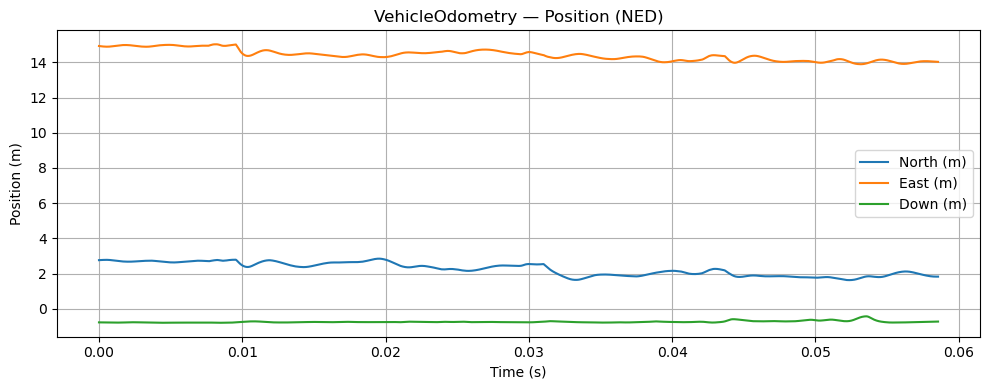

In [3]:
# ===================== PLOTS =====================

# (1) Position (NED)
plt.figure(figsize=(10,4))
plt.plot(time_s, df_vo["pos_north"].to_numpy(), label="North (m)")
plt.plot(time_s, df_vo["pos_east"].to_numpy(),  label="East (m)")
plt.plot(time_s, df_vo["pos_down"].to_numpy(),  label="Down (m)")
plt.xlabel("Time (s)"); plt.ylabel("Position (m)")
plt.title("VehicleOdometry — Position (NED)")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()


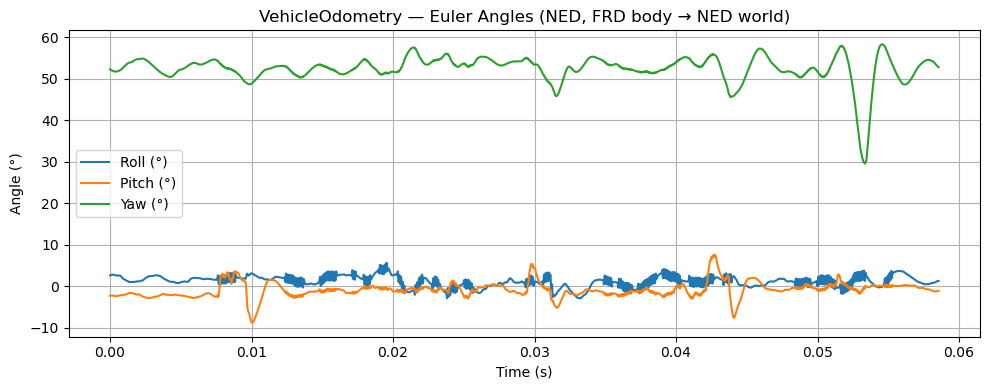

In [4]:
# (2) Euler angles (deg) — robust plotting (no axes handle; unique var names)
roll_deg_eul  = np.asarray(df_vo["roll_deg"],  dtype=float)
pitch_deg_eul = np.asarray(df_vo["pitch_deg"], dtype=float)
yaw_deg_eul   = np.asarray(df_vo["yaw_deg"],   dtype=float)

# Ensure same length
n_eul = min(time_s.size, roll_deg_eul.size, pitch_deg_eul.size, yaw_deg_eul.size)
t_eul = np.asarray(time_s[:n_eul], dtype=float)
roll_deg_eul  = roll_deg_eul[:n_eul]
pitch_deg_eul = pitch_deg_eul[:n_eul]
yaw_deg_eul   = yaw_deg_eul[:n_eul]

# Drop NaNs/Infs consistently
mask_eul = (
    np.isfinite(t_eul) &
    np.isfinite(roll_deg_eul) &
    np.isfinite(pitch_deg_eul) &
    np.isfinite(yaw_deg_eul)
)
t_eul          = t_eul[mask_eul]
roll_deg_eul   = roll_deg_eul[mask_eul]
pitch_deg_eul  = pitch_deg_eul[mask_eul]
yaw_deg_eul    = yaw_deg_eul[mask_eul]

# Plot using pyplot only
plt.figure(figsize=(10, 4))
plt.plot(t_eul, roll_deg_eul,  label="Roll (°)")
plt.plot(t_eul, pitch_deg_eul, label="Pitch (°)")
plt.plot(t_eul, yaw_deg_eul,   label="Yaw (°)")
plt.xlabel("Time (s)")
plt.ylabel("Angle (°)")
plt.title("VehicleOdometry — Euler Angles (NED, FRD body → NED world)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


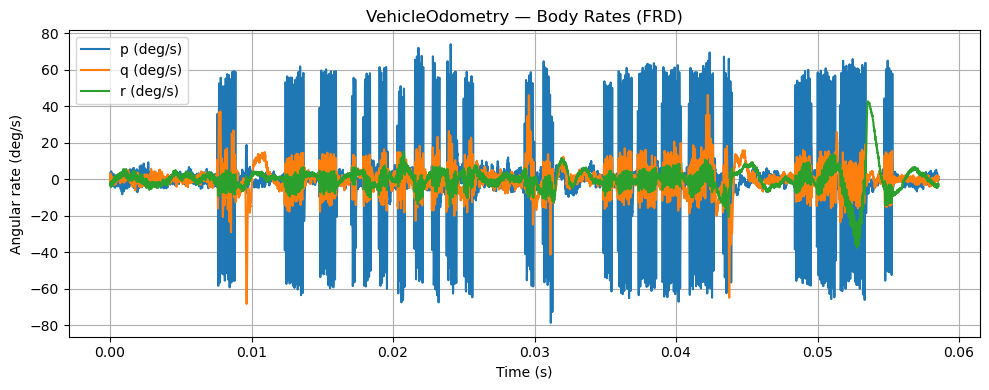

In [5]:
# (3) Angular rates (deg/s) — robust plotting (no axes handle; unique var names)
if have_rates and all(c in df_vo.columns for c in ["p_deg_s", "q_deg_s", "r_deg_s"]):
    p_deg_rates = np.asarray(df_vo["p_deg_s"], dtype=float)
    q_deg_rates = np.asarray(df_vo["q_deg_s"], dtype=float)
    r_deg_rates = np.asarray(df_vo["r_deg_s"], dtype=float)

    # Align series lengths
    n_rates = min(time_s.size, p_deg_rates.size, q_deg_rates.size, r_deg_rates.size)
    t_rates = np.asarray(time_s[:n_rates], dtype=float)
    p_deg_rates = p_deg_rates[:n_rates]
    q_deg_rates = q_deg_rates[:n_rates]
    r_deg_rates = r_deg_rates[:n_rates]

    # Drop rows with NaNs/Infs
    mask_rates = (
        np.isfinite(t_rates) &
        np.isfinite(p_deg_rates) &
        np.isfinite(q_deg_rates) &
        np.isfinite(r_deg_rates)
    )
    t_rates      = t_rates[mask_rates]
    p_deg_rates  = p_deg_rates[mask_rates]
    q_deg_rates  = q_deg_rates[mask_rates]
    r_deg_rates  = r_deg_rates[mask_rates]

    # Plot using pyplot only
    plt.figure(figsize=(10, 4))
    plt.plot(t_rates, p_deg_rates, label="p (deg/s)")
    plt.plot(t_rates, q_deg_rates, label="q (deg/s)")
    plt.plot(t_rates, r_deg_rates, label="r (deg/s)")
    plt.xlabel("Time (s)")
    plt.ylabel("Angular rate (deg/s)")
    plt.title("VehicleOdometry — Body Rates (FRD)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No angular-rate columns found; skipped body-rate plot.")


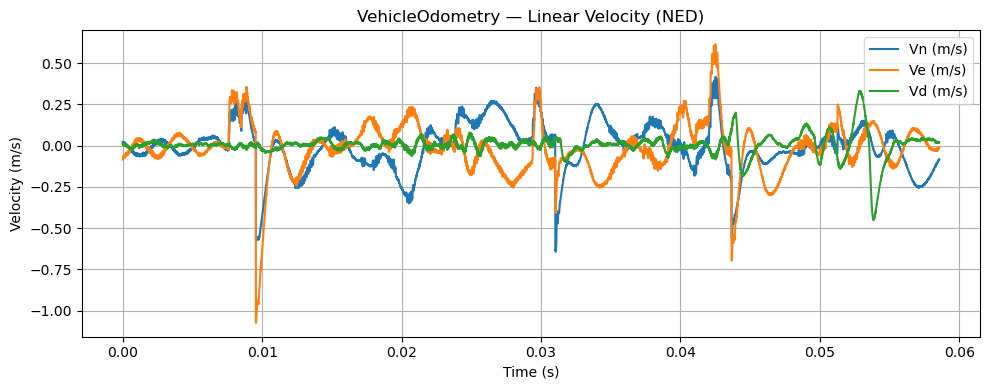

In [6]:
# (4) Linear velocity (NED, m/s) — robust plotting (no axes handle; unique var names)
if have_vel and all(c in df_vo.columns for c in ["vel_north", "vel_east", "vel_down"]):
    vn_vel = np.asarray(df_vo["vel_north"], dtype=float)
    ve_vel = np.asarray(df_vo["vel_east"],  dtype=float)
    vd_vel = np.asarray(df_vo["vel_down"],  dtype=float)

    # Align series lengths
    n_vel = min(time_s.size, vn_vel.size, ve_vel.size, vd_vel.size)
    t_vel = np.asarray(time_s[:n_vel], dtype=float)
    vn_vel, ve_vel, vd_vel = vn_vel[:n_vel], ve_vel[:n_vel], vd_vel[:n_vel]

    # Drop rows with NaNs/Infs
    mask_vel = (
        np.isfinite(t_vel) &
        np.isfinite(vn_vel) &
        np.isfinite(ve_vel) &
        np.isfinite(vd_vel)
    )
    t_vel  = t_vel[mask_vel]
    vn_vel = vn_vel[mask_vel]
    ve_vel = ve_vel[mask_vel]
    vd_vel = vd_vel[mask_vel]

    # Plot using pyplot only
    plt.figure(figsize=(10, 4))
    plt.plot(t_vel, vn_vel, label="Vn (m/s)")
    plt.plot(t_vel, ve_vel, label="Ve (m/s)")
    plt.plot(t_vel, vd_vel, label="Vd (m/s)")
    plt.xlabel("Time (s)")
    plt.ylabel("Velocity (m/s)")
    plt.title("VehicleOdometry — Linear Velocity (NED)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No velocity columns found; skipped linear-velocity plot.")


SENSOR_COMBINED

In [7]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ast

# --- Load the CSV file ---
df_sensor = pd.read_csv("/home/cpsl/px4_ws/outdoor2_log77/csv_out/cpsl_uav_7__fmu__out__sensor_combined.csv")

# Show basic info
print("Data summary:")
df_sensor.info()

# Display first few rows
df_sensor.head()




Data summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5856 entries, 0 to 5855
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   t                                 5856 non-null   float64
 1   t_rel                             5856 non-null   float64
 2   timestamp                         5856 non-null   int64  
 3   gyro_rad                          5856 non-null   object 
 4   gyro_integral_dt                  5856 non-null   int64  
 5   accelerometer_timestamp_relative  5856 non-null   int64  
 6   accelerometer_m_s2                5856 non-null   object 
 7   accelerometer_integral_dt         5856 non-null   int64  
 8   accelerometer_clipping            5856 non-null   int64  
 9   gyro_clipping                     5856 non-null   int64  
 10  accel_calibration_count           5856 non-null   int64  
 11  gyro_calibration_count            5856 non-null   int64

,t,t_rel,timestamp,gyro_rad,gyro_integral_dt,accelerometer_timestamp_relative,accelerometer_m_s2,accelerometer_integral_dt,accelerometer_clipping,gyro_clipping,accel_calibration_count,gyro_calibration_count
0,1.762978e+09,0.000000,1762978446908186,[ 0.04672918 0.00397475 -0.05655316],2505,0,[-3.9459598 -5.291193 -9.103172 ],2505,0,0,3,1
1,1.762978e+09,0.009666,1762978446918203,[-0.03670841 0.044279 -0.06286767],2505,0,[ -0.04966565 -0.26208708 -12.325769 ],2505,0,0,3,1
2,1.762978e+09,0.019687,1762978446928220,[ 0.00460119 -0.02222427 -0.05162516],2505,0,[ 1.7051628 2.3576512 -8.642896 ],2505,0,0,3,1
3,1.762978e+09,0.029737,1762978446938236,[ 0.06885587 0.01599537 -0.01475575],2504,0,[-4.1729803 1.2435476 -8.839492 ],2504,0,0,3,1
4,1.762978e+09,0.039865,1762978446948254,[ 0.00872743 0.01468677 -0.0570647 ],2505,0,[ 0.8682445 -3.0983942 -10.564991 ],2505,0,0,3,1


In [8]:
# 2) Time base in seconds  ---------------------------------------------------
def get_time_seconds(df_sensor):
    # Prefer t_rel if available; otherwise infer µs
    if "t_rel" in df_sensor.columns:
        t = df_sensor["t_rel"].to_numpy(dtype=float)
        return t - t[0]
    for c in ["timestamp_sample", "timestamp", "time_us", "t_us"]:
        if c in df_sensor.columns:
            t = df_sensor[c].to_numpy(dtype=float)
            return (t - t[0]) * 1e-6
    raise KeyError("No time column found (t_rel/timestamp_sample/timestamp/time_us/t_us).")

time_s = get_time_seconds(df_sensor)


In [9]:
# 3) Vector column parser  ---------------------------------------------------
def split_vec_col(series: pd.Series):
    """
    Convert strings like "[a b c]" or "[a, b, c]" into 3 float arrays.
    Uses numpy.fromstring so it's robust to spaces/commas.
    """
    xs, ys, zs = [], [], []
    for s in series.astype(str):
        vals = np.fromstring(s.strip('[]'), sep=' ')
        if vals.size < 3:
            vals = np.fromstring(s.strip('[]'), sep=',')
        if vals.size >= 3:
            xs.append(vals[0]); ys.append(vals[1]); zs.append(vals[2])
        else:
            xs.append(np.nan); ys.append(np.nan); zs.append(np.nan)
    return np.array(xs, float), np.array(ys, float), np.array(zs, float)

In [10]:
# 4) Extract IMU signals  ----------------------------------------------------
# PX4 sensor_combined typically stores these as bracketed strings
ax, ay, az = split_vec_col(df_sensor["accelerometer_m_s2"])
gx, gy, gz = split_vec_col(df_sensor["gyro_rad"])

# Convert gyro rad/s -> deg/s for readability
p_deg_s = np.degrees(gx)
q_deg_s = np.degrees(gy)
r_deg_s = np.degrees(gz)


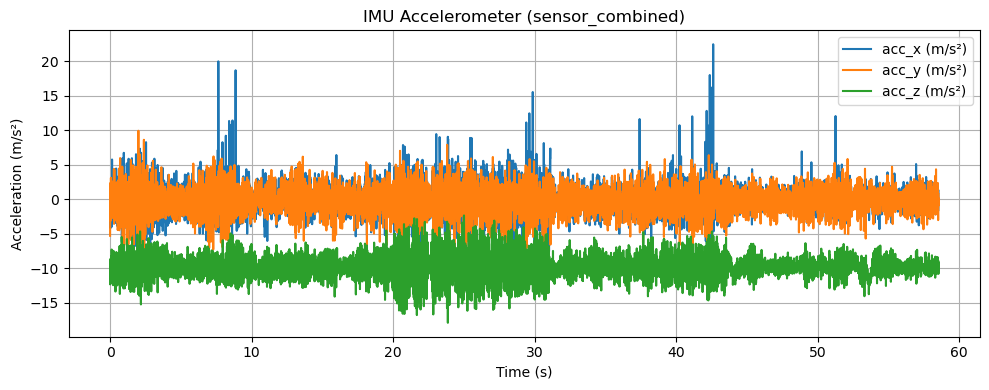

In [11]:

# 5) Plots (each chart in its own figure)  ----------------------------------
plt.figure(figsize=(10, 4))
plt.plot(time_s, ax, label="acc_x (m/s²)")
plt.plot(time_s, ay, label="acc_y (m/s²)")
plt.plot(time_s, az, label="acc_z (m/s²)")
plt.xlabel("Time (s)"); plt.ylabel("Acceleration (m/s²)")
plt.title("IMU Accelerometer (sensor_combined)")
plt.grid(True); plt.legend(); plt.tight_layout()
plt.show()


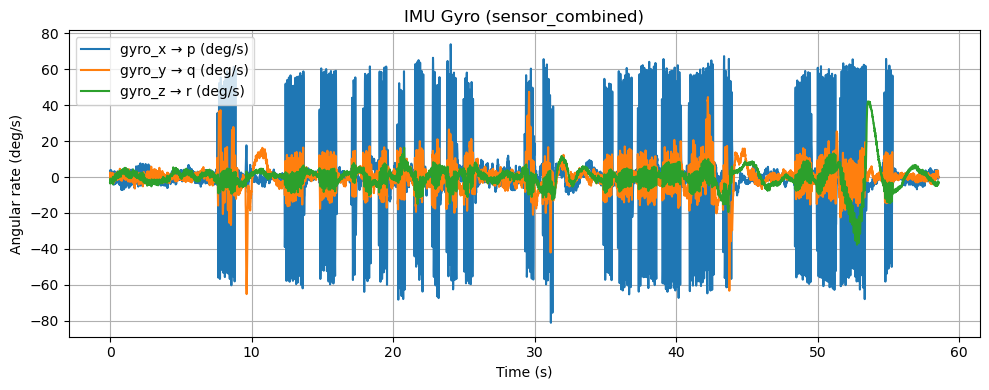

In [12]:

plt.figure(figsize=(10, 4))
plt.plot(time_s, p_deg_s, label="gyro_x → p (deg/s)")
plt.plot(time_s, q_deg_s, label="gyro_y → q (deg/s)")
plt.plot(time_s, r_deg_s, label="gyro_z → r (deg/s)")
plt.xlabel("Time (s)"); plt.ylabel("Angular rate (deg/s)")
plt.title("IMU Gyro (sensor_combined)")
plt.grid(True); plt.legend(); plt.tight_layout()
plt.show()

Overall

In [13]:
import numpy as np
import ast  # only needed if you use vector parsers elsewhere

def time_seconds(df):
    """Pick a time column, convert to seconds, and make relative to first sample."""
    for c in ("t_rel", "timestamp_sample", "timestamp", "time_us"):
        if c in df.columns:
            t = df[c].to_numpy(dtype=float)
            if c in ("timestamp_sample", "timestamp", "time_us"):
                t *= 1e-6  # µs→s
            idx = np.flatnonzero(np.isfinite(t))
            return t - t[idx[0]] if idx.size else t
    raise KeyError("No time column found.")

def interp_to_ref(t_ref, t_src, y_src):
    """
    Interpolate y_src(t_src) onto t_ref.
    Cleans NaNs, sorts, deduplicates t_src; pads NaN outside range.
    Also trims if t_src and y_src lengths differ.
    """
    t_ref = np.asarray(t_ref, dtype=float)
    t_src = np.asarray(t_src, dtype=float)
    y_src = np.asarray(y_src, dtype=float)

    # If lengths differ, trim to the shorter one (keeps time/data pairing)
    if t_src.shape[0] != y_src.shape[0]:
        n = min(t_src.shape[0], y_src.shape[0])
        t_src = t_src[:n]
        y_src = y_src[:n]

    # Remove non-finite
    m = np.isfinite(t_src) & np.isfinite(y_src)
    t_src = t_src[m]; y_src = y_src[m]
    if t_src.size < 2:
        return np.full_like(t_ref, np.nan, dtype=float)

    # Sort by time
    order = np.argsort(t_src)
    t_src = t_src[order]; y_src = y_src[order]

    # Deduplicate times (keep first occurrence)
    t_unique, idx = np.unique(t_src, return_index=True)
    y_unique = y_src[idx]

    return np.interp(t_ref, t_unique, y_unique, left=np.nan, right=np.nan)

# ---------------- time from each source ----------------
t_vo     = time_seconds(df_vo)       # vehicle_odometry CSV
# t_vicon  = time_seconds(df_vicon)    # Vicon CSV
t_sensor = time_seconds(df_sensor)   # sensor_combined CSV (for p_deg_rates)

# choose a common reference time axis (e.g., sensor_combined)
t_ref = t_sensor

# ---------------- interpolate each signal to t_ref ----------------
# From Vicon:
# pitch_ned_vic_i = interp_to_ref(t_ref, t_vicon, pitch_ned_dm.astype(float))
# roll_ned_vic_i  = interp_to_ref(t_ref, t_vicon, roll_ned_dm.astype(float))
# east_vic_i      = interp_to_ref(t_ref, t_vicon, east_dm.astype(float))

# From vehicle_odometry:
roll_vo_i = interp_to_ref(t_ref, t_vo, df_vo["roll_deg"].to_numpy(dtype=float))
east_vo_i = interp_to_ref(t_ref, t_vo, df_vo["pos_east"].to_numpy(dtype=float))

# From sensor_combined (ensure same base as t_sensor):
p_deg_rates_i = interp_to_ref(t_ref, t_sensor, p_deg_rates.astype(float))

# Sanity print
print("Shapes:",
      "t_ref", t_ref.shape,
      # "pitch_ned_vic_i", pitch_ned_vic_i.shape,
      # "roll_ned_vic_i", roll_ned_vic_i.shape,
      "roll_vo_i", roll_vo_i.shape,
      "east_vo_i", east_vo_i.shape,
      # "east_vic_i", east_vic_i.shape,
      "p_deg_rates_i", p_deg_rates_i.shape)


Shapes: t_ref (5856,) roll_vo_i (5856,) east_vo_i (5856,) p_deg_rates_i (5856,)


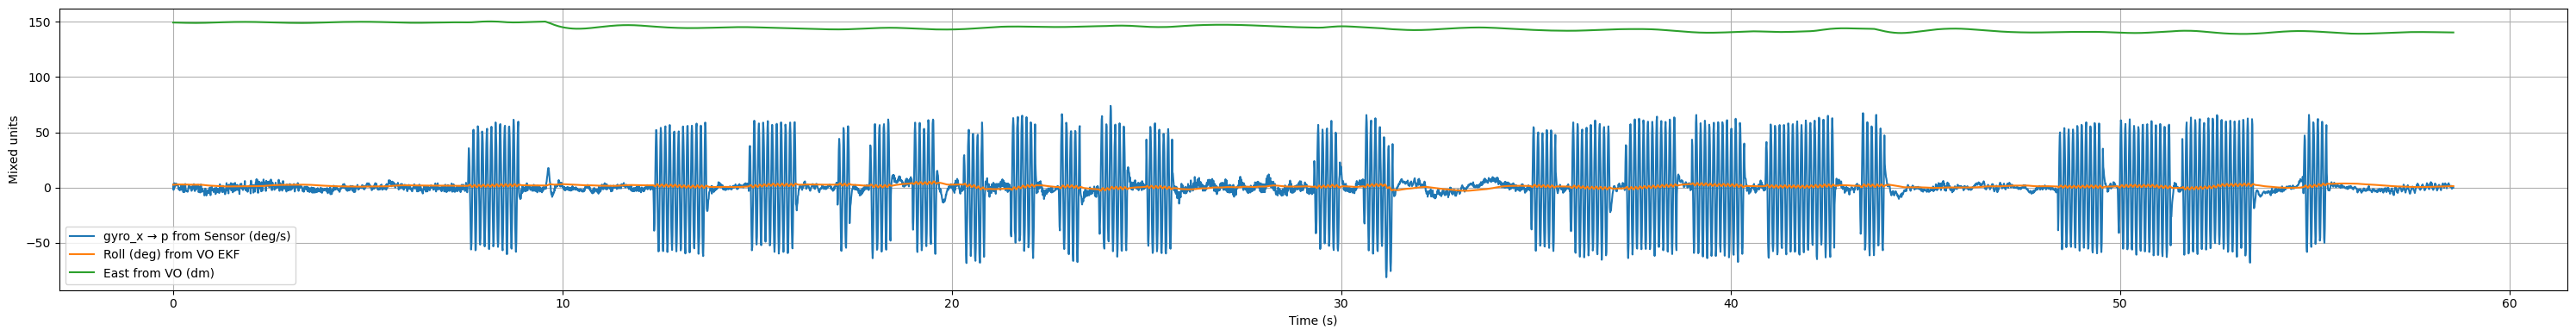

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(30, 4))
plt.plot(time_s, p_deg_s,    label="gyro_x → p from Sensor (deg/s)")
# plt.plot(time_s, p_deg_rates_i,    label="gyro_x → p from VO (deg/s)")
plt.plot(time_s, roll_vo_i,  label="Roll (deg) from VO EKF")
# plt.plot(time_s, roll_ned_vic_i, label="Roll (deg) from Vicon")
plt.plot(time_s, 10*east_vo_i,  label="East from VO (dm)")
# plt.plot(time_s, 10*east_vic_i, label="East from Vicon (demeaned, dm)")
# plt.ylim(-10, 10)
plt.xlabel("Time (s)"); plt.ylabel("Mixed units")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()


In [15]:
# ---------- Interpolate NORTH & PITCH to t_ref ----------

# ---- Vicon sources (robust fallbacks) ----
# north: use demeaned if you already computed it; else raw pos_north
# if 'north_dm' in globals():
#     north_vicon_src = np.asarray(north_dm, dtype=float)
# elif "pos_north" in df_vicon.columns:
#     north_vicon_src = df_vicon["pos_north"].to_numpy(dtype=float)
# else:
#     raise KeyError("Need Vicon north: provide `north_dm` or df_vicon['pos_north'].")

# pitch: use your demeaned pitch if present; else look for a Vicon pitch col (deg)
# if 'pitch_ned_dm' in globals():
#     pitch_vicon_src_deg = np.asarray(pitch_ned_dm, dtype=float)
# elif "pitch_deg" in df_vicon.columns:
#     pitch_vicon_src_deg = df_vicon["pitch_deg"].to_numpy(dtype=float)
# else:
#     raise KeyError("Need Vicon pitch: provide `pitch_ned_dm` or df_vicon['pitch_deg'].")

# Interpolate Vicon to the common time base
# north_vic_i  = interp_to_ref(t_ref, t_vicon, north_vicon_src)
# pitch_vic_i  = interp_to_ref(t_ref, t_vicon, pitch_vicon_src_deg)

# ---- VO (vehicle_odometry) sources ----
if "pos_north" not in df_vo.columns:
    raise KeyError("df_vo must contain 'pos_north' for VO north position.")
if "pitch_deg" not in df_vo.columns:
    raise KeyError("df_vo must contain 'pitch_deg' (computed earlier from quaternion).")

north_vo_i = interp_to_ref(t_ref, t_vo, df_vo["pos_north"].to_numpy(dtype=float))
pitch_vo_i = interp_to_ref(t_ref, t_vo, df_vo["pitch_deg"].to_numpy(dtype=float))

# Alias for plotting to match your earlier code
time_s = np.asarray(t_ref, dtype=float)

# Quick sanity
print("Interpolated arrays:")
# print("  north_vic_i:", north_vic_i.shape, " pitch_vic_i:", pitch_vic_i.shape)
print("  north_vo_i :", north_vo_i.shape,  " pitch_vo_i :", pitch_vo_i.shape)


Interpolated arrays:
  north_vo_i : (5856,)  pitch_vo_i : (5856,)


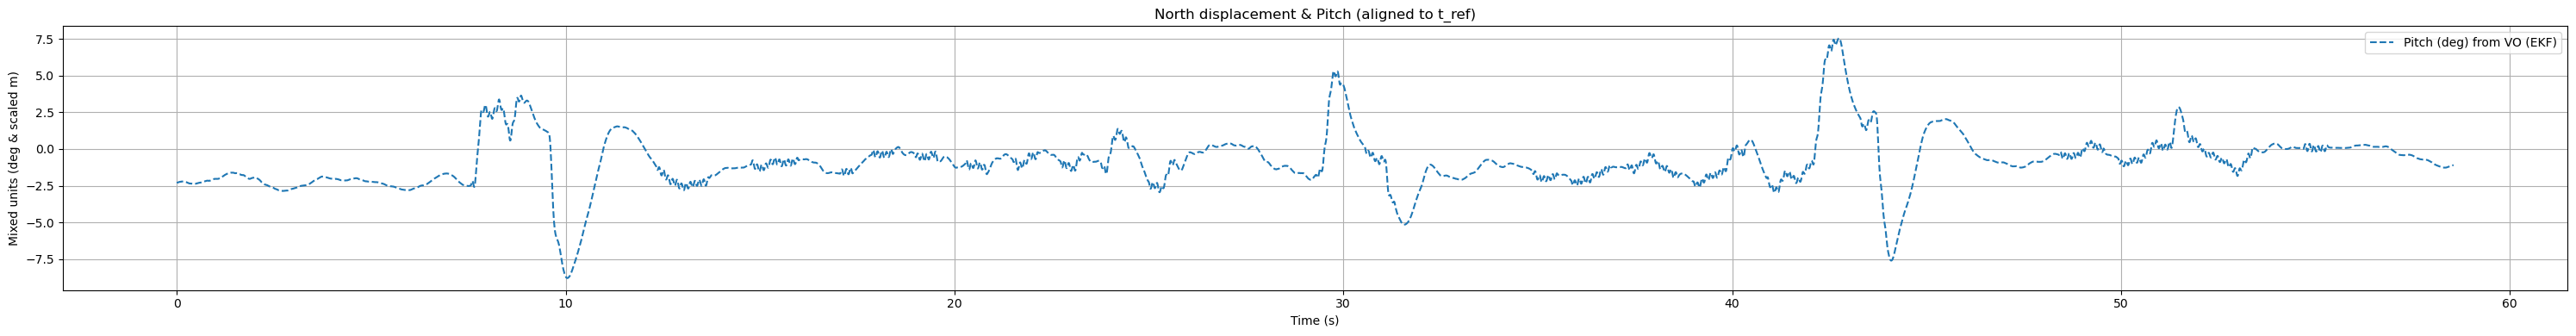

In [16]:
import matplotlib.pyplot as plt

SCALE_NORTH = 10.0  # scale meters -> decimeters for overplotting with degrees

plt.figure(figsize=(30, 4))
# plt.plot(time_s, pitch_vic_i,        label="Pitch (deg) from Vicon", lw=1.5)
plt.plot(time_s, pitch_vo_i,         label="Pitch (deg) from VO (EKF)", lw=1.5, ls='--')
# plt.plot(time_s, SCALE_NORTH*north_vic_i, label=f"North from Vicon (×{SCALE_NORTH} for scale)", lw=1.0)
# plt.plot(time_s, SCALE_NORTH*north_vo_i,  label=f"North from VO (×{SCALE_NORTH} for scale)",   lw=1.0, ls='--')

plt.xlabel("Time (s)")
plt.ylabel("Mixed units (deg & scaled m)")
plt.title("North displacement & Pitch (aligned to t_ref)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [17]:
import numpy as np
import matplotlib.pyplot as plt

# ===================== Core helpers =====================

def moving_average(x, win_samples: int):
    """Simple centered moving average (same-size output)."""
    win = int(max(1, win_samples))
    if win == 1:
        return np.asarray(x, float)
    k = np.ones(win, float) / win
    return np.convolve(np.asarray(x, float), k, mode="same")

def interp_to_ref(t_ref, t_src, y_src):
    """
    Interpolate y_src(t_src) onto t_ref.
    Cleans NaNs, sorts, deduplicates times; pads with NaN outside range.
    """
    t_ref = np.asarray(t_ref, float)
    t_src = np.asarray(t_src, float)
    y_src = np.asarray(y_src, float)

    # align lengths if a logger dropped samples in one of the arrays
    n = min(t_src.size, y_src.size)
    t_src, y_src = t_src[:n], y_src[:n]

    m = np.isfinite(t_src) & np.isfinite(y_src)
    t_src, y_src = t_src[m], y_src[m]
    if t_src.size < 2:
        return np.full_like(t_ref, np.nan, float)

    order = np.argsort(t_src)
    t_src, y_src = t_src[order], y_src[order]

    t_unique, idx = np.unique(t_src, return_index=True)
    y_unique = y_src[idx]

    return np.interp(t_ref, t_unique, y_unique, left=np.nan, right=np.nan)

def cycle_bounds_from_signal(
    t, y, *, osc_smooth_s=0.03, trend_s=0.50
):
    """
    Detect oscillation cycles via positive-going zero crossings of a
    smoothed+detrended version of y.

    Returns:
      tc      : (K,) time at center of each cycle
      bounds  : list[(i0, i1)] index bounds over ORIGINAL arrays (inclusive end)
      trend   : slow baseline used for detrending (same length as y)
    """
    t = np.asarray(t, float)
    y = np.asarray(y, float)

    m = np.isfinite(t) & np.isfinite(y)
    t, y = t[m], y[m]
    if t.size < 4:
        return np.array([]), [], np.full_like(t, np.nan, float)

    dt = np.median(np.diff(t))
    if not np.isfinite(dt) or dt <= 0:
        return np.array([]), [], np.full_like(t, np.nan, float)

    osc_win   = max(1, int(round(osc_smooth_s / dt)))
    trend_win = max(3, int(round(trend_s   / dt)) | 1)   # force odd

    y_s   = moving_average(y, osc_win)
    trend = moving_average(y_s, trend_win)
    osc   = y_s - trend

    s = np.sign(osc)
    s[s == 0] = 1
    zc_pos = np.where((s[:-1] < 0) & (s[1:] > 0))[0]
    if zc_pos.size < 2:
        return np.array([]), [], trend

    tc, bounds = [], []
    for i0, i1 in zip(zc_pos[:-1], zc_pos[1:]):
        # use interior of each cycle [i0+1, i1]
        if (i1 - i0) >= 2:
            bounds.append((i0+1, i1))
            tc.append(0.5*(t[i0+1] + t[i1]))

    return np.asarray(tc), bounds, trend

def per_cycle_mean_from_bounds(y, bounds):
    """Return per-cycle mean of y over the provided bounds list[(i0,i1)]."""
    y = np.asarray(y, float)
    means = []
    for i0, i1 in bounds:
        seg = y[i0:i1+1]
        means.append(np.nan if seg.size == 0 else float(np.nanmean(seg)))
    return np.asarray(means, float)

# ===================== Plotting APIs =====================

def plot_cycle_mean(
    t, y, *,
    label="signal",
    color=None,
    use_reference=None,
    osc_smooth_s=0.03,
    trend_s=0.50,
    show_raw=True,
    raw_alpha=0.25,
    step_kwargs=None,
    scatter_kwargs=None,
):
    """
    Plot raw series (optional) plus per-cycle means (as steps+markers).
    If use_reference is provided as a (t_ref, y_ref) pair, cycles are segmented
    on that reference but means are computed on y. Otherwise y self-segments.
    """
    t = np.asarray(t, float)
    y = np.asarray(y, float)
    n = min(t.size, y.size)
    t, y = t[:n], y[:n]

    if use_reference is None:
        tc, bounds, _ = cycle_bounds_from_signal(t, y, osc_smooth_s=osc_smooth_s, trend_s=trend_s)
    else:
        t_ref, y_ref = use_reference
        t_ref = np.asarray(t_ref, float)
        y_ref = np.asarray(y_ref, float)
        nref  = min(t_ref.size, y_ref.size)
        t_ref, y_ref = t_ref[:nref], y_ref[:nref]
        tc, bounds, _ = cycle_bounds_from_signal(t_ref, y_ref, osc_smooth_s=osc_smooth_s, trend_s=trend_s)

        # Convert reference time centers to indices on our t for plotting markers/steps
        # (we'll just use tc as x for the means; means are computed from bounds on y)
    means = per_cycle_mean_from_bounds(y, bounds)

    # Plot
    if show_raw:
        plt.plot(t, y, lw=0.9, alpha=raw_alpha, color=color, label=f"{label} (raw)")

    step_kwargs  = {} if step_kwargs is None else dict(step_kwargs)
    scatter_kwargs = {} if scatter_kwargs is None else dict(scatter_kwargs)

    plt.step(tc, means, where="mid", lw=2.0, color=color, label=f"{label} — cycle mean", **step_kwargs)
    plt.scatter(tc, means, s=20, zorder=3, color=color, **scatter_kwargs)

    return tc, means  # handy if you want to compute further stats

def plot_multi_cycle_means(
    t, series_dict,
    *,
    reference_label=None,
    independent=False,
    osc_smooth_s=0.03,
    trend_s=0.50,
    show_raw=True,
):
    """
    series_dict: {label: y}
    If independent=False: cycles are taken from the reference (first key or reference_label).
    If independent=True: each series is segmented independently.
    """
    colors = plt.rcParams['axes.prop_cycle'].by_key().get('color', None)

    if not independent:
        if reference_label is None:
            reference_label = next(iter(series_dict.keys()))
        tcref, bounds, _ = cycle_bounds_from_signal(
            t, series_dict[reference_label], osc_smooth_s=osc_smooth_s, trend_s=trend_s
        )

        for i, (lbl, y) in enumerate(series_dict.items()):
            color = None if colors is None else colors[i % len(colors)]
            if show_raw:
                plt.plot(t[:len(y)], y[:len(y)], lw=0.9, alpha=0.25, color=color, label=f"{lbl} (raw)")
            means = per_cycle_mean_from_bounds(y, bounds)
            plt.step(tcref, means, where="mid", lw=2.0, color=color, label=f"{lbl} — cycle mean")
            plt.scatter(tcref, means, s=20, zorder=3, color=color)
        return

    # independent segmentation per series
    for i, (lbl, y) in enumerate(series_dict.items()):
        color = None if colors is None else colors[i % len(colors)]
        if show_raw:
            plt.plot(t[:len(y)], y[:len(y)], lw=0.9, alpha=0.25, color=color, label=f"{lbl} (raw)")
        tc, bounds, _ = cycle_bounds_from_signal(t, y, osc_smooth_s=osc_smooth_s, trend_s=trend_s)
        means = per_cycle_mean_from_bounds(y, bounds)
        plt.step(tc, means, where="mid", lw=2.0, color=color, label=f"{lbl} — cycle mean")
        plt.scatter(tc, means, s=20, zorder=3, color=color)


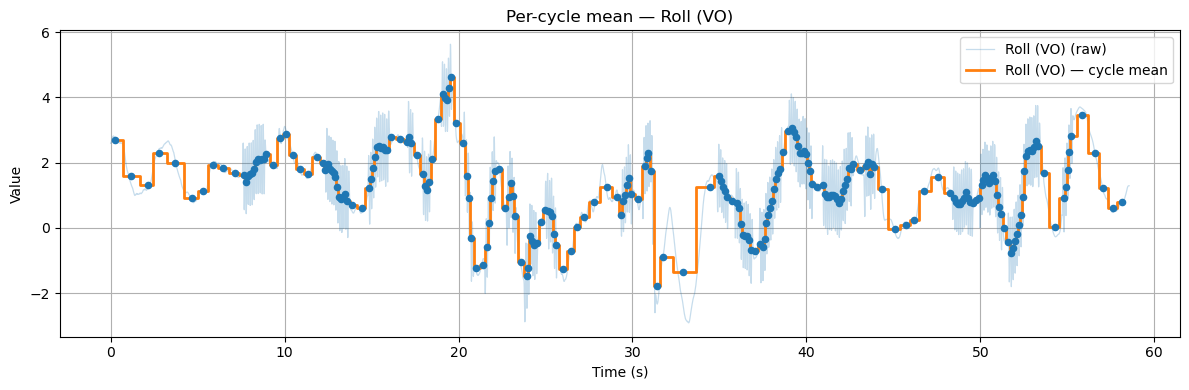

In [18]:
plt.figure(figsize=(12,4))
tc_roll, m_roll = plot_cycle_mean(time_s, roll_vo_i, label="Roll (VO)", osc_smooth_s=0.04, trend_s=0.6)
plt.xlabel("Time (s)"); plt.ylabel("Value"); plt.title("Per-cycle mean — Roll (VO)")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()


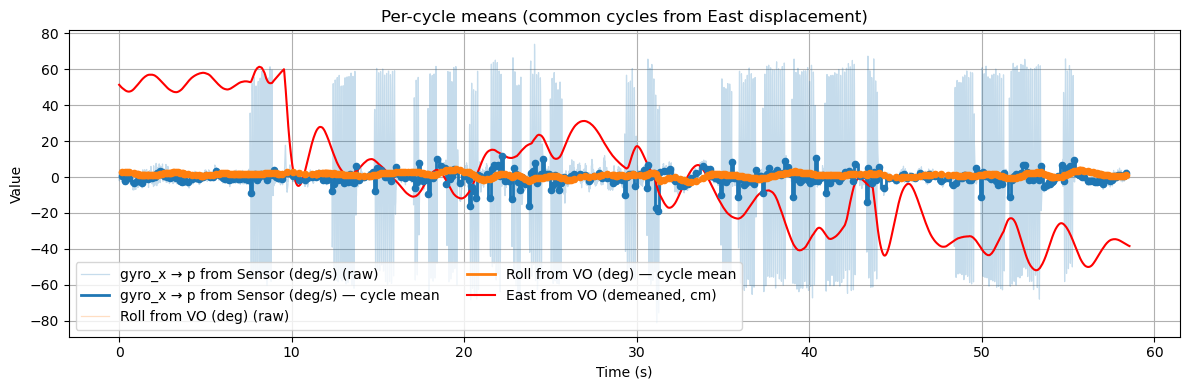

In [38]:
# Build East from VO (demeaned, dm)
east_vo = df_vo["pos_east"].to_numpy().astype(float)
east_vo_i = east_vo - np.nanmean(east_vo)   # or: east_vo - east_vo[0]  (baseline at t=0)

plt.figure(figsize=(12,4))
plot_multi_cycle_means(
    time_s,
    {
        "gyro_x → p from Sensor (deg/s)": p_deg_s,
        "Roll from VO (deg)":            roll_vo_i,
    },
    # reference_label="East from VO (dm)",  # ← use this if you want cycles defined by East
    osc_smooth_s=0.04, trend_s=0.6, show_raw=True
)
# --- Build "East from VO (demeaned, dm)" aligned to time_s ---

# 1) Grab VO east and a VO time vector
east_vo = df_vo["pos_east"].to_numpy(dtype=float)

if "time_s" in df_vo.columns:
    t_vo = df_vo["time_s"].to_numpy(dtype=float)
elif "timestamp" in df_vo.columns:
    ts = df_vo["timestamp"].to_numpy(dtype=float)
    # Heuristic: convert big integer timestamps to seconds (assume microseconds)
    scale = 1e-6 if (np.nanmax(ts) - np.nanmin(ts)) > 1e7 else 1.0
    t_vo = (ts - ts[0]) * scale
else:
    # Fallback: assume uniform sampling over the span of time_s
    t_vo = np.linspace(time_s[0], time_s[-1], len(east_vo))

# 2) Clean & make strictly increasing for interpolation
m = np.isfinite(t_vo) & np.isfinite(east_vo)
t_vo = t_vo[m]
east_vo = east_vo[m]
t_vo, uniq_idx = np.unique(t_vo, return_index=True)
east_vo = east_vo[uniq_idx]

# 3) Resample VO east onto time_s and demean
east_vo_resampled = np.interp(time_s, t_vo, east_vo)
east_vo_i = east_vo_resampled - np.nanmean(east_vo_resampled)

# 4) Now safe to plot against time_s
plt.plot(time_s, 100* east_vo_i, label="East from VO (demeaned, cm)", color="red")


plt.xlabel("Time (s)"); plt.ylabel("Value")
plt.title("Per-cycle means (common cycles from East displacement)")
plt.grid(True); plt.legend(ncol=2); plt.tight_layout(); plt.show()




paper figures

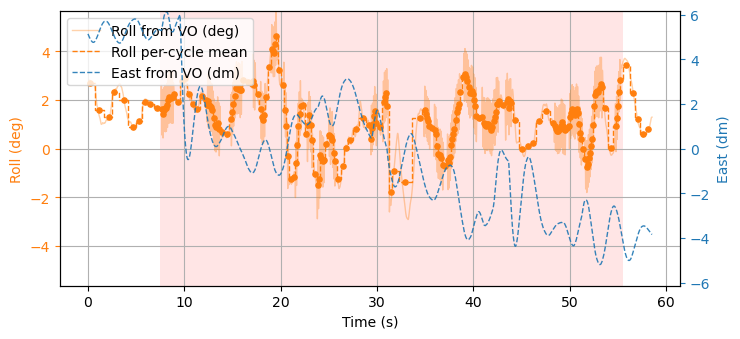

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- colors ----------
roll_color = 'tab:orange'   # VO roll + means
east_color = 'tab:blue'     # VO east (dm)

# ---------- helpers ----------
def moving_average(x, win):
    win = int(max(1, win))
    x = np.asarray(x, float)
    if win == 1 or x.size == 0:
        return x
    k = np.ones(win, float) / win
    return np.convolve(x, k, mode="same")

def per_cycle_means(t, y, osc_smooth_s=0.04, trend_s=0.6):
    t = np.asarray(t, float)
    y = np.asarray(y, float)
    m = np.isfinite(t) & np.isfinite(y)
    t, y = t[m], y[m]
    if t.size < 4:
        return np.array([]), np.array([]), None

    dt = np.median(np.diff(t))
    if dt <= 0 or not np.isfinite(dt):
        return np.array([]), np.array([]), None

    osc_win   = max(1, int(round(osc_smooth_s / dt)))
    trend_win = max(3, int(round(trend_s / dt)) | 1)

    y_s   = moving_average(y, osc_win)
    trend = moving_average(y_s, trend_win)
    osc   = y_s - trend

    sgn = np.sign(osc)
    sgn[sgn == 0] = 1
    zc_pos = np.where((sgn[:-1] < 0) & (sgn[1:] > 0))[0]
    if zc_pos.size < 2:
        return np.array([]), np.array([]), None

    tc, means = [], []
    for i0, i1 in zip(zc_pos[:-1], zc_pos[1:]):
        seg = y[i0+1:i1+1]
        if seg.size < 2:
            continue
        means.append(np.mean(seg))
        tc.append(0.5 * (t[i0+1] + t[i1]))
    return np.asarray(tc), np.asarray(means), None

# ---------- per-cycle means for VO roll ----------
tc_roll, m_roll, _ = per_cycle_means(
    time_s,
    roll_vo_i,
    osc_smooth_s=0.04,
    trend_s=0.6
)

# ---------- build East from VO (demeaned, dm) aligned to time_s ----------
east_vo = df_vo["pos_east"].to_numpy(dtype=float)

if "time_s" in df_vo.columns:
    t_vo = df_vo["time_s"].to_numpy(dtype=float)
elif "timestamp" in df_vo.columns:
    ts = df_vo["timestamp"].to_numpy(dtype=float)
    scale = 1e-6 if (np.nanmax(ts) - np.nanmin(ts)) > 1e7 else 1.0
    t_vo = (ts - ts[0]) * scale
else:
    t_vo = np.linspace(time_s[0], time_s[-1], len(east_vo))

m = np.isfinite(t_vo) & np.isfinite(east_vo)
t_vo = t_vo[m]
east_vo = east_vo[m]
t_vo, uniq_idx = np.unique(t_vo, return_index=True)
east_vo = east_vo[uniq_idx]

east_vo_resampled = np.interp(time_s, t_vo, east_vo)
east_vo_i = east_vo_resampled - np.nanmean(east_vo_resampled)
east_vo_dm = 10.0 * east_vo_i  # m -> dm

# ---------- single-axes plot (no T_CUT) ----------
fig, ax = plt.subplots(1, 1, figsize=(7.5, 3.5))
ax_r = ax.twinx()

# raw roll (background)
line_roll_raw, = ax.plot(
    time_s, roll_vo_i,
    color=roll_color, alpha=0.35, lw=1.0,
    label="Roll from VO (deg)"
)

# roll per-cycle mean
line_roll_mean, = ax.step(
    tc_roll, m_roll, where='mid',
    color=roll_color, ls='--', lw=1.0, alpha=1.0,
    label="Roll per-cycle mean"
)
ax.scatter(tc_roll, m_roll, s=14, color=roll_color, marker='o', zorder=3)

# east from VO (dm) on right axis
line_east, = ax_r.plot(
    time_s, east_vo_dm,
    color=east_color, ls='--', lw=1.0, alpha=0.9,
    label="East from VO (dm)"
)

# attack window shading: 7.5s -> 55.5s
ax.axvspan(7.5, 55.5, facecolor='red', alpha=0.10, zorder=0)

# symmetric y-lims about 0
r_abs = np.nanmax(np.abs(np.concatenate([roll_vo_i, m_roll[np.isfinite(m_roll)]])))
if not np.isfinite(r_abs) or r_abs == 0:
    r_abs = 1.0
ax.set_ylim(-r_abs, r_abs)

e_abs = np.nanmax(np.abs(east_vo_dm))
if not np.isfinite(e_abs) or e_abs == 0:
    e_abs = 1.0
ax_r.set_ylim(-e_abs, e_abs)

# cosmetics
ax.set_xlabel("Time (s)")
ax.set_ylabel("Roll (deg)")
ax_r.set_ylabel("East (dm)")
ax.grid(True)

# color axes
ax.tick_params(axis='y', colors=roll_color)
ax.yaxis.label.set_color(roll_color)
ax_r.tick_params(axis='y', colors=east_color)
ax_r.yaxis.label.set_color(east_color)

# legend
ax.legend(
    [line_roll_raw, line_roll_mean, line_east],
    ["Roll from VO (deg)", "Roll per-cycle mean", "East from VO (dm)"],
    loc="upper left"
)

plt.tight_layout()
plt.show()


In [ ]:
fig.savefig("roll_est_y.png", dpi=300, bbox_inches='tight') 


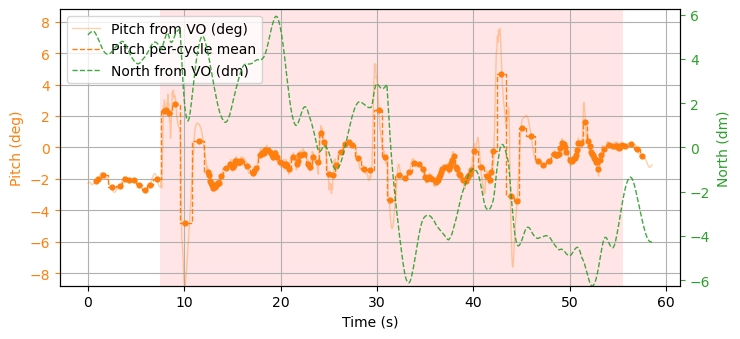

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- colors ----------
pitch_color = 'tab:orange'   # VO pitch + means
north_color = 'tab:green'    # VO north (dm)

# ---------- helpers ----------
def moving_average(x, win):
    win = int(max(1, win))
    x = np.asarray(x, float)
    if win == 1 or x.size == 0:
        return x
    k = np.ones(win, float) / win
    return np.convolve(x, k, mode="same")

def per_cycle_means(t, y, osc_smooth_s=0.04, trend_s=0.6):
    t = np.asarray(t, float)
    y = np.asarray(y, float)
    m = np.isfinite(t) & np.isfinite(y)
    t, y = t[m], y[m]
    if t.size < 4:
        return np.array([]), np.array([]), None

    dt = np.median(np.diff(t))
    if dt <= 0 or not np.isfinite(dt):
        return np.array([]), np.array([]), None

    osc_win   = max(1, int(round(osc_smooth_s / dt)))
    trend_win = max(3, int(round(trend_s / dt)) | 1)

    y_s   = moving_average(y, osc_win)
    trend = moving_average(y_s, trend_win)
    osc   = y_s - trend

    sgn = np.sign(osc)
    sgn[sgn == 0] = 1
    zc_pos = np.where((sgn[:-1] < 0) & (sgn[1:] > 0))[0]
    if zc_pos.size < 2:
        return np.array([]), np.array([]), None

    tc, means = [], []
    for i0, i1 in zip(zc_pos[:-1], zc_pos[1:]):
        seg = y[i0+1:i1+1]
        if seg.size < 2:
            continue
        means.append(np.mean(seg))
        tc.append(0.5 * (t[i0+1] + t[i1]))
    return np.asarray(tc), np.asarray(means), None

# ---------- per-cycle means for VO pitch ----------
tc_pitch, m_pitch, _ = per_cycle_means(
    time_s,
    pitch_vo_i,
    osc_smooth_s=0.04,
    trend_s=0.6
)

# ---------- build North from VO (demeaned, dm) aligned to time_s ----------
north_vo = df_vo["pos_north"].to_numpy(dtype=float)

if "time_s" in df_vo.columns:
    t_vo = df_vo["time_s"].to_numpy(dtype=float)
elif "timestamp" in df_vo.columns:
    ts = df_vo["timestamp"].to_numpy(dtype=float)
    scale = 1e-6 if (np.nanmax(ts) - np.nanmin(ts)) > 1e7 else 1.0
    t_vo = (ts - ts[0]) * scale
else:
    t_vo = np.linspace(time_s[0], time_s[-1], len(north_vo))

m = np.isfinite(t_vo) & np.isfinite(north_vo)
t_vo = t_vo[m]
north_vo = north_vo[m]
t_vo, uniq_idx = np.unique(t_vo, return_index=True)
north_vo = north_vo[uniq_idx]

north_vo_resampled = np.interp(time_s, t_vo, north_vo)
north_vo_i = north_vo_resampled - np.nanmean(north_vo_resampled)
north_vo_dm = 10.0 * north_vo_i  # m -> dm

# ---------- single-axes plot ----------
fig, ax = plt.subplots(1, 1, figsize=(7.5, 3.5))
ax_r = ax.twinx()

# raw pitch (background)
line_pitch_raw, = ax.plot(
    time_s, pitch_vo_i,
    color=pitch_color, alpha=0.35, lw=1.0,
    label="Pitch from VO (deg)"
)

# pitch per-cycle mean
line_pitch_mean, = ax.step(
    tc_pitch, m_pitch, where='mid',
    color=pitch_color, ls='--', lw=1.0, alpha=1.0,
    label="Pitch per-cycle mean"
)
ax.scatter(tc_pitch, m_pitch, s=12, color=pitch_color, marker='o', zorder=3)

# north from VO (dm) on right axis
line_north, = ax_r.plot(
    time_s, north_vo_dm,
    color=north_color, ls='--', lw=1.0, alpha=0.9,
    label="North from VO (dm)"
)

# attack window shading: 7.5s -> 55.5s
ax.axvspan(7.5, 55.5, facecolor='red', alpha=0.10, zorder=0)

# symmetric y-lims about 0
p_abs = np.nanmax(np.abs(np.concatenate([pitch_vo_i, m_pitch[np.isfinite(m_pitch)]])))
if not np.isfinite(p_abs) or p_abs == 0:
    p_abs = 1.0
ax.set_ylim(-p_abs, p_abs)

n_abs = np.nanmax(np.abs(north_vo_dm))
if not np.isfinite(n_abs) or n_abs == 0:
    n_abs = 1.0
ax_r.set_ylim(-n_abs, n_abs)

# cosmetics
ax.set_xlabel("Time (s)")
ax.set_ylabel("Pitch (deg)")
ax_r.set_ylabel("North (dm)")
ax.grid(True)

# color axes
ax.tick_params(axis='y', colors=pitch_color)
ax.yaxis.label.set_color(pitch_color)
ax_r.tick_params(axis='y', colors=north_color)
ax_r.yaxis.label.set_color(north_color)

# legend
ax.legend(
    [line_pitch_raw, line_pitch_mean, line_north],
    ["Pitch from VO (deg)", "Pitch per-cycle mean", "North from VO (dm)"],
    loc="upper left"
)

plt.tight_layout()
plt.show()


In [ ]:
fig.savefig("pitch_est_x.png", dpi=300, bbox_inches='tight') 

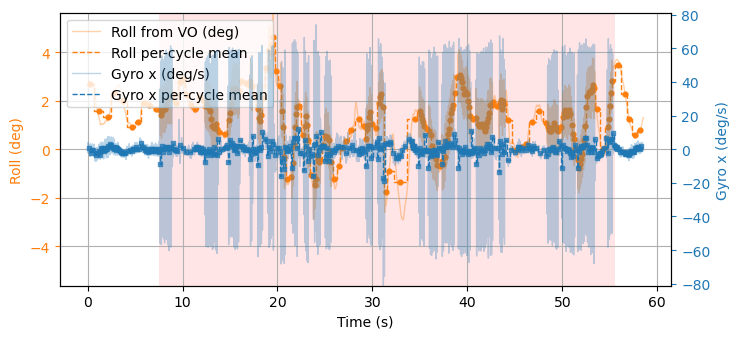

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- colors ----------
roll_color = 'tab:orange'   # roll angle + means
rate_color = 'tab:blue'     # gyro x + means

# ---------- helpers ----------
def moving_average(x, win):
    win = int(max(1, win))
    x = np.asarray(x, float)
    if win == 1 or x.size == 0:
        return x
    k = np.ones(win, float) / win
    return np.convolve(x, k, mode="same")

def per_cycle_means(t, y, osc_smooth_s=0.04, trend_s=0.6):
    t = np.asarray(t, float)
    y = np.asarray(y, float)
    m = np.isfinite(t) & np.isfinite(y)
    t, y = t[m], y[m]
    if t.size < 4:
        return np.array([]), np.array([]), None

    dt = np.median(np.diff(t))
    if dt <= 0 or not np.isfinite(dt):
        return np.array([]), np.array([]), None

    osc_win   = max(1, int(round(osc_smooth_s / dt)))
    trend_win = max(3, int(round(trend_s / dt)) | 1)

    y_s   = moving_average(y, osc_win)
    trend = moving_average(y_s, trend_win)
    osc   = y_s - trend

    sgn = np.sign(osc)
    sgn[sgn == 0] = 1
    zc_pos = np.where((sgn[:-1] < 0) & (sgn[1:] > 0))[0]
    if zc_pos.size < 2:
        return np.array([]), np.array([]), None

    tc, means = [], []
    for i0, i1 in zip(zc_pos[:-1], zc_pos[1:]):
        seg = y[i0+1:i1+1]
        if seg.size < 2:
            continue
        means.append(np.mean(seg))
        tc.append(0.5 * (t[i0+1] + t[i1]))
    return np.asarray(tc), np.asarray(means), None

# ---------- per-cycle means (roll & gyro x) ----------
tc_roll, m_roll, _ = per_cycle_means(time_s, roll_vo_i, osc_smooth_s=0.04, trend_s=0.6)
tc_rate, m_rate, _ = per_cycle_means(time_s, p_deg_s,  osc_smooth_s=0.04, trend_s=0.6)

# ---------- plot ----------
fig, ax = plt.subplots(1, 1, figsize=(7.5, 3.5))
ax_r = ax.twinx()

# roll raw (background)
line_roll_raw, = ax.plot(
    time_s, roll_vo_i,
    color=roll_color, alpha=0.35, lw=1.0,
    label="Roll from VO (deg)"
)

# roll per-cycle mean
line_roll_mean, = ax.step(
    tc_roll, m_roll, where='mid',
    color=roll_color, ls='--', lw=1.0, alpha=1.0,
    label="Roll per-cycle mean"
)
ax.scatter(tc_roll, m_roll, s=12, color=roll_color, marker='o', zorder=3)

# gyro x raw (right axis, background)
line_rate_raw, = ax_r.plot(
    time_s, p_deg_s,
    color=rate_color, alpha=0.30, lw=1.0,
    label="Gyro x (deg/s)"
)

# gyro x per-cycle mean
line_rate_mean, = ax_r.step(
    tc_rate, m_rate, where='mid',
    color=rate_color, ls='--', lw=1.0, alpha=1.0,
    label="Gyro x per-cycle mean"
)
ax_r.scatter(tc_rate, m_rate, s=10, color=rate_color, marker='s', alpha=0.7, zorder=3)

# attack window shading
ax.axvspan(7.5, 55.5, facecolor='red', alpha=0.10, zorder=0)

# symmetric y-lims about 0
roll_abs = np.nanmax(np.abs(np.concatenate([roll_vo_i, m_roll[np.isfinite(m_roll)]]))) or 1.0
rate_abs = np.nanmax(np.abs(np.concatenate([p_deg_s,   m_rate[np.isfinite(m_rate)]]))) or 1.0
ax.set_ylim(-roll_abs, roll_abs)
ax_r.set_ylim(-rate_abs, rate_abs)

# cosmetics
ax.set_xlabel("Time (s)")
ax.set_ylabel("Roll (deg)")
ax_r.set_ylabel("Gyro x (deg/s)")
ax.grid(True)

# axis colors
ax.tick_params(axis='y', colors=roll_color)
ax.yaxis.label.set_color(roll_color)
ax_r.tick_params(axis='y', colors=rate_color)
ax_r.yaxis.label.set_color(rate_color)

# legend
ax.legend(
    [line_roll_raw, line_roll_mean, line_rate_raw, line_rate_mean],
    ["Roll from VO (deg)", "Roll per-cycle mean", "Gyro x (deg/s)", "Gyro x per-cycle mean"],
    loc="upper left"
)

plt.tight_layout()
plt.show()


In [ ]:
fig.savefig("gyro_x_vo_roll.png", dpi=300, bbox_inches='tight') 

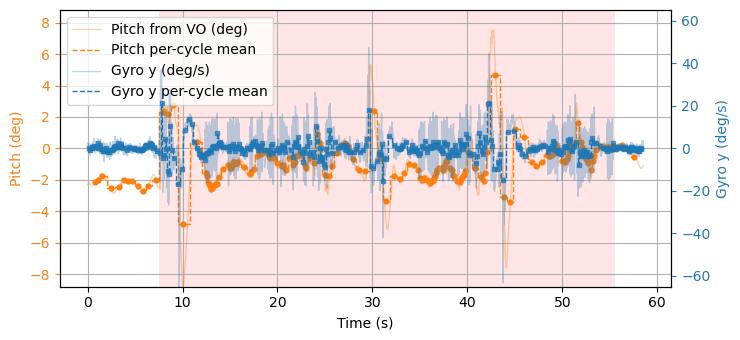

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- colors ----------
ang_color  = 'tab:orange'   # pitch angle + means
rate_color = 'tab:blue'     # gyro y + means

# ---------- helpers ----------
def moving_average(x, win):
    win = int(max(1, win))
    x = np.asarray(x, float)
    if win == 1 or x.size == 0:
        return x
    k = np.ones(win, float) / win
    return np.convolve(x, k, mode="same")

def per_cycle_means(t, y, osc_smooth_s=0.04, trend_s=0.6):
    t = np.asarray(t, float)
    y = np.asarray(y, float)
    m = np.isfinite(t) & np.isfinite(y)
    t, y = t[m], y[m]
    if t.size < 4:
        return np.array([]), np.array([]), None

    dt = np.median(np.diff(t))
    if dt <= 0 or not np.isfinite(dt):
        return np.array([]), np.array([]), None

    osc_win   = max(1, int(round(osc_smooth_s / dt)))
    trend_win = max(3, int(round(trend_s / dt)) | 1)

    y_s   = moving_average(y, osc_win)
    trend = moving_average(y_s, trend_win)
    osc   = y_s - trend

    sgn = np.sign(osc)
    sgn[sgn == 0] = 1
    zc_pos = np.where((sgn[:-1] < 0) & (sgn[1:] > 0))[0]
    if zc_pos.size < 2:
        return np.array([]), np.array([]), None

    tc, means = [], []
    for i0, i1 in zip(zc_pos[:-1], zc_pos[1:]):
        seg = y[i0+1:i1+1]
        if seg.size < 2:
            continue
        means.append(np.mean(seg))
        tc.append(0.5 * (t[i0+1] + t[i1]))
    return np.asarray(tc), np.asarray(means), None

# ---------- per-cycle means (pitch & gyro y) ----------
tc_pitch, m_pitch, _ = per_cycle_means(time_s, pitch_vo_i, osc_smooth_s=0.04, trend_s=0.6)
tc_rate,  m_rate,  _ = per_cycle_means(time_s, q_deg_s,    osc_smooth_s=0.04, trend_s=0.6)  # q_deg_s = gyro Y

# ---------- plot ----------
fig, ax = plt.subplots(1, 1, figsize=(7.5, 3.5))
ax_r = ax.twinx()

# pitch raw (background)
line_pitch_raw, = ax.plot(
    time_s, pitch_vo_i,
    color=ang_color, alpha=0.35, lw=1.0,
    label="Pitch from VO (deg)"
)

# pitch per-cycle mean
line_pitch_mean, = ax.step(
    tc_pitch, m_pitch, where='mid',
    color=ang_color, ls='--', lw=1.0, alpha=1.0,
    label="Pitch per-cycle mean"
)
ax.scatter(tc_pitch, m_pitch, s=12, color=ang_color, marker='o', zorder=3)

# gyro y raw (right axis, background)
line_rate_raw, = ax_r.plot(
    time_s, q_deg_s,
    color=rate_color, alpha=0.30, lw=1.0,
    label="Gyro y (deg/s)"
)

# gyro y per-cycle mean
line_rate_mean, = ax_r.step(
    tc_rate, m_rate, where='mid',
    color=rate_color, ls='--', lw=1.0, alpha=1.0,
    label="Gyro y per-cycle mean"
)
ax_r.scatter(tc_rate, m_rate, s=10, color=rate_color, marker='s', alpha=0.7, zorder=3)

# attack window shading
ax.axvspan(7.5, 55.5, facecolor='red', alpha=0.10, zorder=0)

# symmetric y-lims about 0
pitch_abs = np.nanmax(np.abs(np.concatenate([pitch_vo_i, m_pitch[np.isfinite(m_pitch)]]))) or 1.0
rate_abs  = np.nanmax(np.abs(np.concatenate([q_deg_s,    m_rate[np.isfinite(m_rate)]]))) or 1.0
ax.set_ylim(-pitch_abs, pitch_abs)
ax_r.set_ylim(-rate_abs,  rate_abs)

# cosmetics
ax.set_xlabel("Time (s)")
ax.set_ylabel("Pitch (deg)")
ax_r.set_ylabel("Gyro y (deg/s)")
ax.grid(True)

# axis colors
ax.tick_params(axis='y', colors=ang_color)
ax.yaxis.label.set_color(ang_color)
ax_r.tick_params(axis='y', colors=rate_color)
ax_r.yaxis.label.set_color(rate_color)

# legend
ax.legend(
    [line_pitch_raw, line_pitch_mean, line_rate_raw, line_rate_mean],
    ["Pitch from VO (deg)", "Pitch per-cycle mean", "Gyro y (deg/s)", "Gyro y per-cycle mean"],
    loc="upper left"
)

plt.tight_layout()
plt.show()


In [ ]:
fig.savefig("gyro_y_vo_pitch.png", dpi=300, bbox_inches='tight') 